# Run Analysis

Loads TensorBoard scalar data from `runs/{FOLDER_NAME}/{exp_group}/{i}/` and plots
metrics aggregated across the numbered runs (mean line + 95% confidence band).

Data loading lives in `data_loader.py`; plotting in `plot_tools.py`. This notebook
only sets parameters and renders outputs.

## 1. Imports

In [271]:
import os
import sys
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# The utility modules (data_loader.py, plot_tools.py) live next to this notebook
# in data_analysis/. Make them importable whether the kernel starts in
# data_analysis/ or the repo root by walking up from the cwd to find them.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (os.path.join(d, "data_analysis"), d):
            if os.path.isfile(os.path.join(cand, "data_loader.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import data_loader as dl   # data loading + reduction (single source of truth)
import plot_tools as pt    # plotting + styling (single source of truth)

## 2. Global parameters

Folder, CI width, x-axis, output folder, and the shared `STYLE` object.

In [ ]:
# Root folder that contains the experiment-group sub-folders (runs/{FOLDER_NAME}).
PROJECT_ROOT = dl.find_project_root()
RUNS_ROOT = dl.runs_root()
FOLDER_NAME = "ent_rotKP_test" #"baseline_swap"

# Confidence band: mean +/- CI_Z * SEM. 1.96 -> ~95% CI.
CI_Z = 1.96

# Keep only the top-N runs per group, ranked by each run's peak SUCCESS_METRIC.
# -1 keeps all runs.
TOP_N = -1
SUCCESS_METRIC = "Episode / Success rate"

# Shared x-axis for every time-series plot. XLIM is (min, max) or None.
XLABEL = "Env Steps"
XLIM = (0, 12500)

# One dated plots folder per run (re-running same day overwrites):
# runs/{FOLDER_NAME}/plots_{date}/{name}.svg
PLOTS_DIR = os.path.join(RUNS_ROOT, FOLDER_NAME,
                         f"plots_{datetime.now().strftime('%Y%m%d')}")

# Styling/context object threaded through every plot call. Display names + colors
# default to the glued_rot_rew controller ablation (see plot_tools); override
# STYLE.display_names / STYLE.group_colors here for a different run set.
STYLE = pt.PlotStyle(ci_z=CI_Z, xlabel=XLABEL, xlim=XLIM, plots_dir=PLOTS_DIR)
STEP_CEILING = STYLE.step_ceiling

## 3. Load data

`DATA = { exp_group: [ {tag: (steps, values)}, ... one dict per run ] }`.

In [273]:
DATA = dl.load_data(FOLDER_NAME, RUNS_ROOT)
DATA = dl.filter_top_n(DATA, TOP_N, SUCCESS_METRIC, STEP_CEILING)

en6d_rot: 3 runs loaded
ent_1e-4: 3 runs loaded
ent_1e-5: 3 runs loaded


## 4. Best-point summary table (LaTeX)

In [274]:
# Best-point summary table (LaTeX). For each run, freeze the step where
# SELECTION_METRIC peaks (within the XLIM ceiling) and read every TABLE_METRIC
# there; report mean +/- 95% CI across a method's runs. Best per column is bolded.
SELECTION_METRIC = "Episode / Success rate"

# One dict per column: tag, header, higher_is_better, unit (LaTeX, escape % as
# \\%), scale (e.g. 100 for percent), decimals (defaults to DEFAULT_DECIMALS).
TABLE_METRICS = [
    {"tag": "Episode / Success rate",       "header": "Success Rate",    "higher_is_better": True,  "unit": "\\%",    "scale": 100, "decimals": 1},
    {"tag": "success_times",                "header": "Success Time",    "higher_is_better": False, "unit": "steps", "scale": 1,   "decimals": 1},
    {"tag": "Reward / Total reward (mean)", "header": "Total Reward",    "higher_is_better": True,  "unit": "",      "scale": 1,   "decimals": 1},
    {"tag": "logs_rew/contact_penalty",     "header": "Contact Penalty", "higher_is_better": False, "unit": "",      "scale": 1,   "decimals": 2},
]

# Row order (display names OR raw folders). Only loaded methods appear.
ROW_ORDER = ["Fixed", "VICES", "Cholesky", "GAS (fixed rot)", "GAS"]
DEFAULT_DECIMALS = 3

TABLE_GROUPS = pt.resolve_row_order(DATA, ROW_ORDER, STYLE)
latex = pt.build_latex_table(DATA, SELECTION_METRIC, TABLE_METRICS, TABLE_GROUPS,
                             STYLE, default_decimals=DEFAULT_DECIMALS)
print(latex)

[row-order] not a loaded method, skipping: 'Fixed'
[row-order] not a loaded method, skipping: 'VICES'
[row-order] not a loaded method, skipping: 'Cholesky'
[row-order] not a loaded method, skipping: 'GAS (fixed rot)'
[row-order] not a loaded method, skipping: 'GAS'
% Requires \usepackage{booktabs} in your preamble.
\begin{tabular}{lcccc}
\toprule
Method & Success Rate (\%) $\uparrow$ & Success Time (steps) $\downarrow$ & Total Reward $\uparrow$ & Contact Penalty $\downarrow$ \\
\midrule
\bottomrule
\end{tabular}


## 5. Success rate

saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/Episode_Success rate.svg


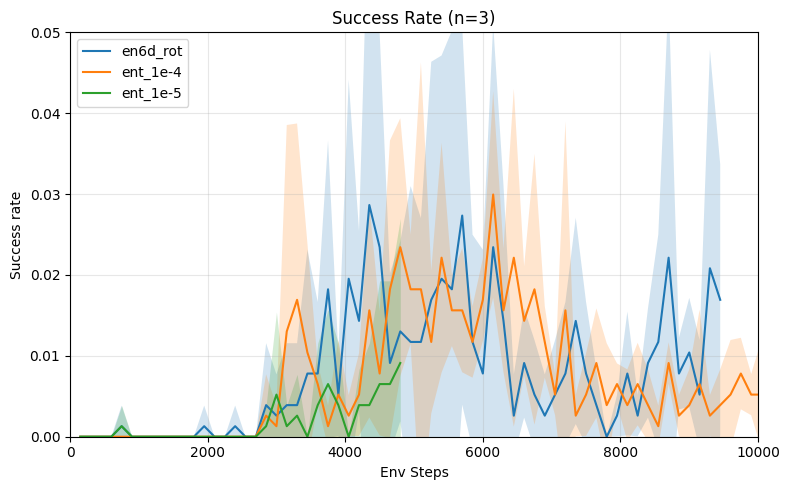

In [275]:
metric = 'Episode / Success rate'
ylabel = 'Success rate'
title = 'Success Rate (Best)'
legend_loc = 'upper left'
ylim = (0, 0.05)

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 5b. Success rate (smoothed)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/Episode_Success rate (smoothed).svg


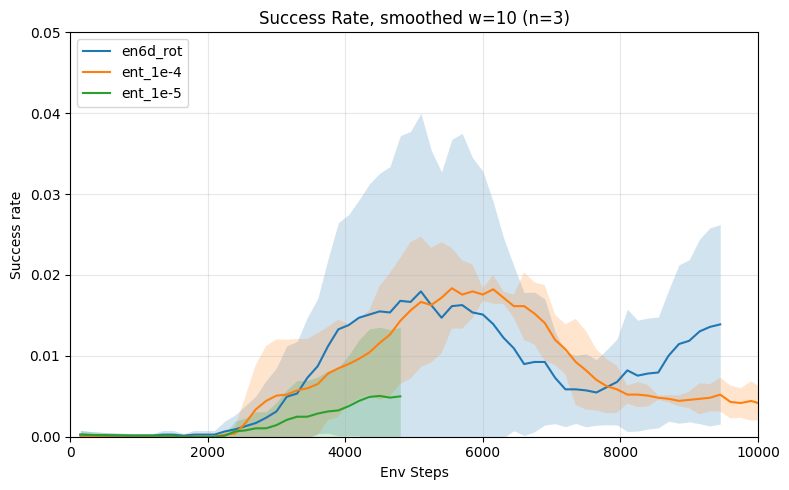

In [276]:
# Same success-rate data, but each run's curve is passed through a centered
# moving average first so the lines are readable. SMOOTH_WINDOW = 1 disables it.
SMOOTH_WINDOW = 10

metric = "Episode / Success rate"
ylabel = "Success rate"
title = f"Success Rate, smoothed w={SMOOTH_WINDOW} (Best)"
legend_loc = "upper left"
ylim = (0, 0.05)

smoothed = dl.smooth_data(DATA, metric, SMOOTH_WINDOW)
ax = pt.plot_metric(smoothed, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric + " (smoothed)", STYLE)
plt.show()

## 6. Total reward

saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/Reward_Total reward (mean).svg


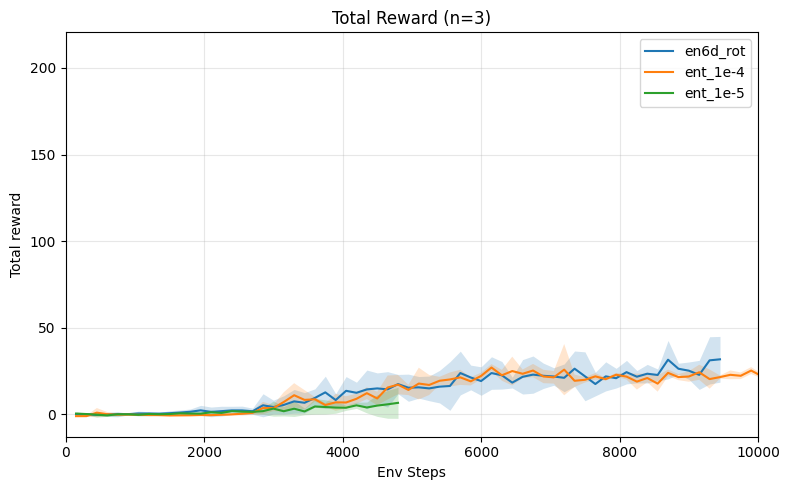

In [277]:
metric = 'Reward / Total reward (mean)'
ylabel = 'Total reward'
title = 'Total Reward (n=3)'
legend_loc = 'best'
ylim = None

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 7. Contact penalty

saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/logs_rew_contact_penalty.svg


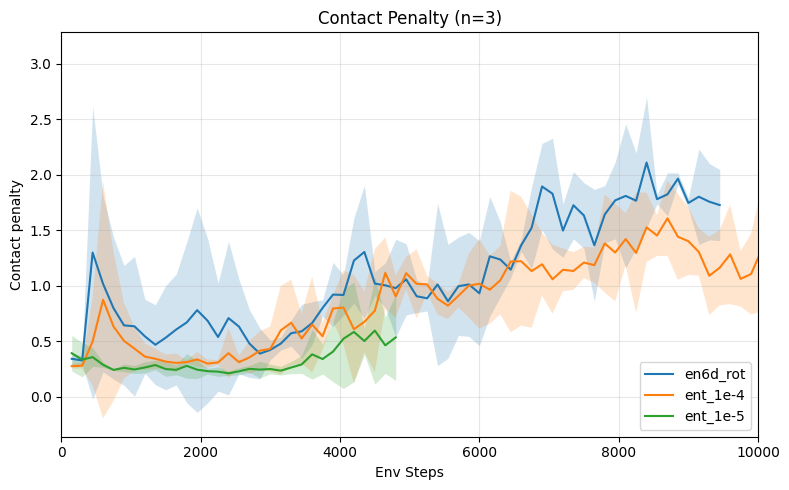

In [278]:
metric = 'logs_rew/contact_penalty'
ylabel = 'Contact penalty'
title = 'Contact Penalty (n=3)'
legend_loc = 'best'
ylim = None

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 8. Success times

[skip] metric 'success_times' not found in: ent_1e-5
saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/success_times.svg


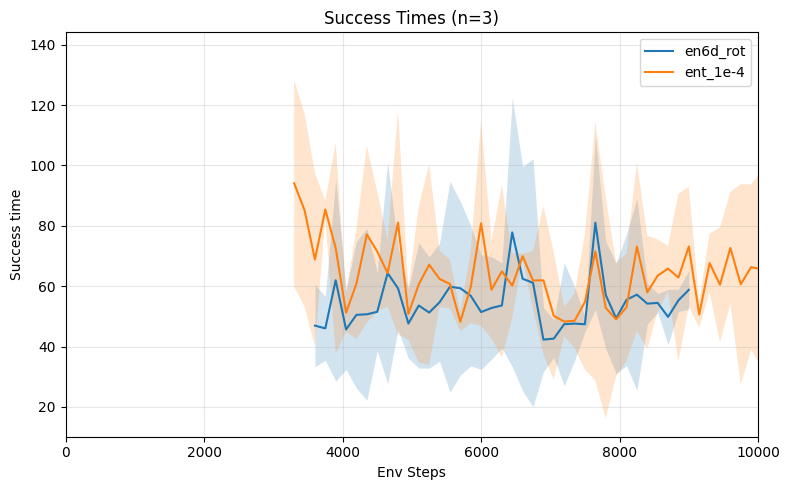

In [279]:
metric = 'success_times'
ylabel = 'Success time'
title = 'Success Times (n=3)'
legend_loc = 'best'
ylim = None

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 9. In-contact Z

[skip] metric 'Contact / In-Contact Z' not found in: en6d_rot
[skip] metric 'Contact / In-Contact Z' not found in: ent_1e-4
[skip] metric 'Contact / In-Contact Z' not found in: ent_1e-5
saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/Contact_In-Contact Z.svg


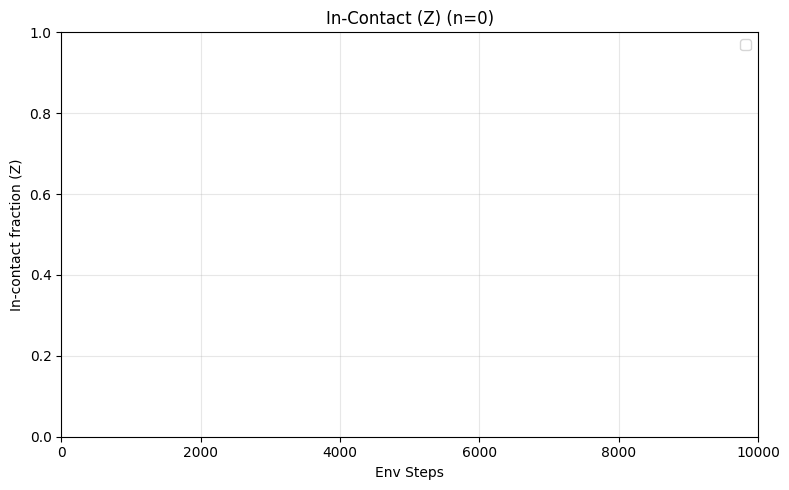

In [280]:
metric = 'Contact / In-Contact Z'
ylabel = 'In-contact fraction (Z)'
title = 'In-Contact (Z) (n=3)'
legend_loc = 'best'
ylim = (0, 1)

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 10. In-contact any

[skip] metric 'Contact / In-Contact Any' not found in: en6d_rot
[skip] metric 'Contact / In-Contact Any' not found in: ent_1e-4
[skip] metric 'Contact / In-Contact Any' not found in: ent_1e-5
saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/Contact_In-Contact Any.svg


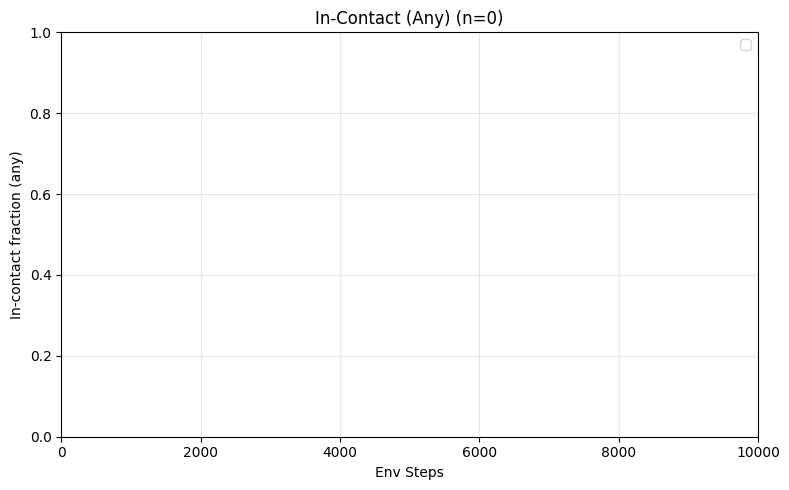

In [281]:
metric = 'Contact / In-Contact Any'
ylabel = 'In-contact fraction (any)'
title = 'In-Contact (Any) (n=3)'
legend_loc = 'best'
ylim = (0, 1)

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 11. Engagement rate

saved /home/hunter/generalized_hybrid_vic_action_space/runs/ent_rotKP_test/plots_20260630/Episode_Engagement rate.svg


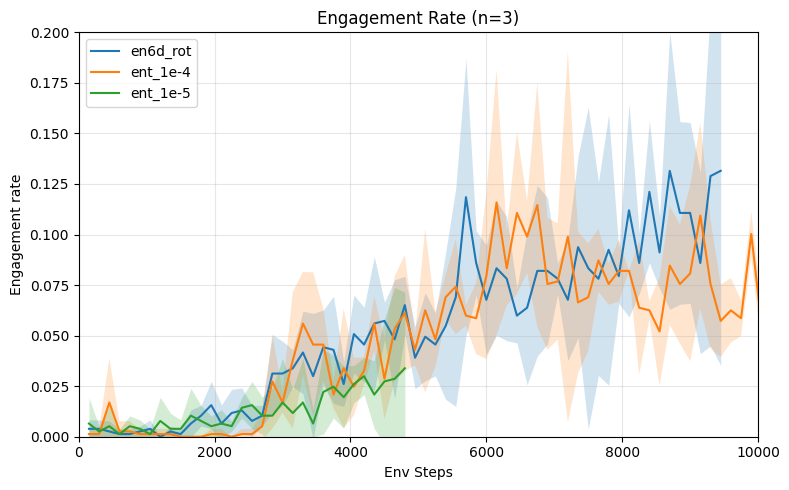

In [282]:
metric = 'Episode / Engagement rate'
ylabel = 'Engagement rate'
title = 'Engagement Rate (n=3)'
legend_loc = 'best'
ylim = (0, 0.2)

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()